In [12]:
# Put the project directory on the path to make sure we can import PyNitride
import sys, os
sys.path.append(os.path.abspath("../"))

In [13]:
%matplotlib notebook
import matplotlib.pyplot as plt
import matplotlib
from pynitride import ParamDB
pmdb=ParamDB(units='neu')
to_units=pmdb.to_units
nm,cm=pmdb.get_constants("nm,cm")
from pynitride.poissolve.devices import gan_qwhemt

In [14]:
qwh=gan_qwhemt(2*nm,5*nm,25*nm,1000*nm,1e16*cm**-3)

<IPython.core.display.Javascript object>


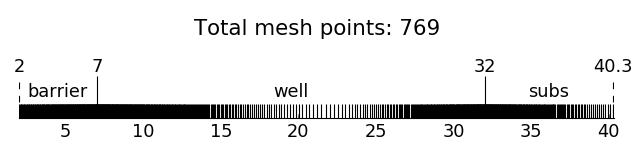

In [15]:
qwh[1].plot_mesh()

In [16]:
from os.path import expanduser, join
from pynitride import ROOT_DIR, Value
from pynitride.poissolve.snider import import_1dp_input, import_1dp_output, convert_1dpmat_to_PyNitride
from pynitride.poissolve.solvers import Coupled_Schrodinger_Poisson
from pynitride.poissolve.visual import plot_carrierFV, plot_wavefunctions

In [17]:
convert_1dpmat_to_PyNitride('/usr/local/bin/materials.txt','1dp.txt')
pmdb.clear()
pmdb._dict['T']=300
pmdb.read_file('1dp.txt')

indir=expanduser(join(ROOT_DIR,"tests","1DPoisson_Runs"))
m,sm=import_1dp_input(join(indir,"GaN_AlN_HEMT"),pmdb=pmdb)
#import_1dp_output(join(indir,"GaN_AlN_HEMT"),m,sm)
#plot_carrierFV(m)

pmdb._dict['material=GaN']['surface=GenericMetal']={}
pmdb._dict['material=GaN']['surface=GenericMetal']['electronbarrier']=Value(".6*eV")


In [19]:
csp=Coupled_Schrodinger_Poisson(qwh[0],schrodinger=qwh[1])
csp.solve(low_act=3,rise=40)


oops
oops
oops
oops
oops
oops
oops
oops
oops
oops
oops
oops
oops
oops
oops
oops
oops
oops
oops
No materials include DeepDonor as a dopant.
oops
No materials include DeepAcceptor as a dopant.
Semi-classical success (max err=2.3e-16) after 2 refinement iterations
Full success (max err=9.7e-11) after 28 refinement iterations


In [20]:
matplotlib.rcParams.update({'font.size': 16})

<IPython.core.display.Javascript object>


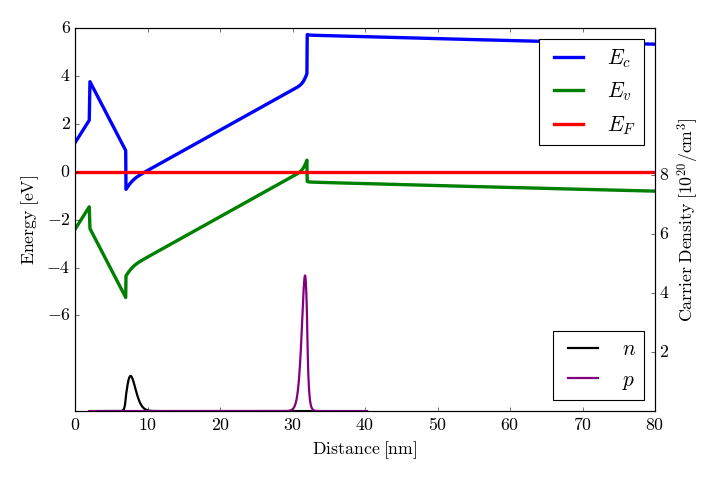

In [21]:
plt.figure(figsize=(9,6))
#ax1=plt.subplot(211)
qwh[0]['Ec'].plot(linewidth=3,label='$E_c$')
qwh[0]['Ev'].plot(linewidth=3,label='$E_v$')
qwh[0]['EF'].plot(linewidth=3,label='$E_F$')
plt.ylim(-10,6)
lyticks=[-6,-4,-2,0,2,4,6]
plt.yticks(lyticks,["$\mathrm{{{:d}}}$".format(lyt) for lyt in lyticks])

plt.ylabel("$\mathrm{Energy\;[eV]}$")
plt.xlabel("$\mathrm{Distance\;[nm]}$")
plt.legend(loc='upper right').draggable()

#plt.subplot(212,sharex=ax1)
plt.twinx()
plt.xlim(0,80)
xticks=[int(xt) for xt in plt.xticks()[0]]
plt.xticks(xticks,["$\mathrm{{{:d}}}$".format(xt) for xt in xticks])


to_units(qwh[1]['n'],'1e20/cm**3').plot('k',linewidth=2,label='$n$')
to_units(qwh[1]['p'],'1e20/cm**3').plot('purple',linewidth=2,label='$p$')

plt.ylim(0,13)
ryticks=[2,4,6,8]
plt.yticks(ryticks,["$\mathrm{{{:d}}}$".format(ryt) for ryt in ryticks])
plt.ylabel(r"$\mathrm{Carrier\;Density\;[}10^{20}/\mathrm{cm}^3\mathrm{]}$")



plt.legend(loc='lower right').draggable()
plt.tight_layout()
#plt.yscale('log')
#qwh[1]['Psi_e_'][0,:].plot()

In [33]:
to_units(qwh[0]._layers[0].material['hole.HH.mzs'],"m_e")

0.569

In [27]:
qwh[0]._layers[1].material['Eg']

6.139999999999999

In [10]:
t=plt.yticks()[1][0]

In [11]:
t.g

AttributeError: 'Text' object has no attribute 'g'